In [268]:
# !pip install pycbc
# !pip install gwosc
# !pip install gwpy

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc import waveform
import pycbc.psd
from pycbc import filter
from pycbc import frame
from pycbc.psd import interpolate, inverse_spectrum_truncation
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

In [269]:
#Load all files

In [8]:
from google.colab import files
uploaded = files.upload()

Saving strain-3.gwf to strain-3.gwf


In [10]:
from gwpy.io.gwf import get_channel_names

channels = get_channel_names("strain-2.gwf")
print(channels)

['L1:DCS-CALIB_STRAIN_C01']


In [11]:
data_1 = TimeSeries.read("strain-1.gwf", channel='L1:DCS-CALIB_STRAIN_C01')
data_2 = TimeSeries.read("strain-2.gwf", channel='L1:DCS-CALIB_STRAIN_C01')
data_3 = TimeSeries.read("strain-3.gwf", channel='L1:DCS-CALIB_STRAIN_C01')

In [12]:
psd_1 = data_1.psd(fftlength=4)
psd_2 = data_2.psd(fftlength=4)
psd_3 = data_3.psd(fftlength=4)

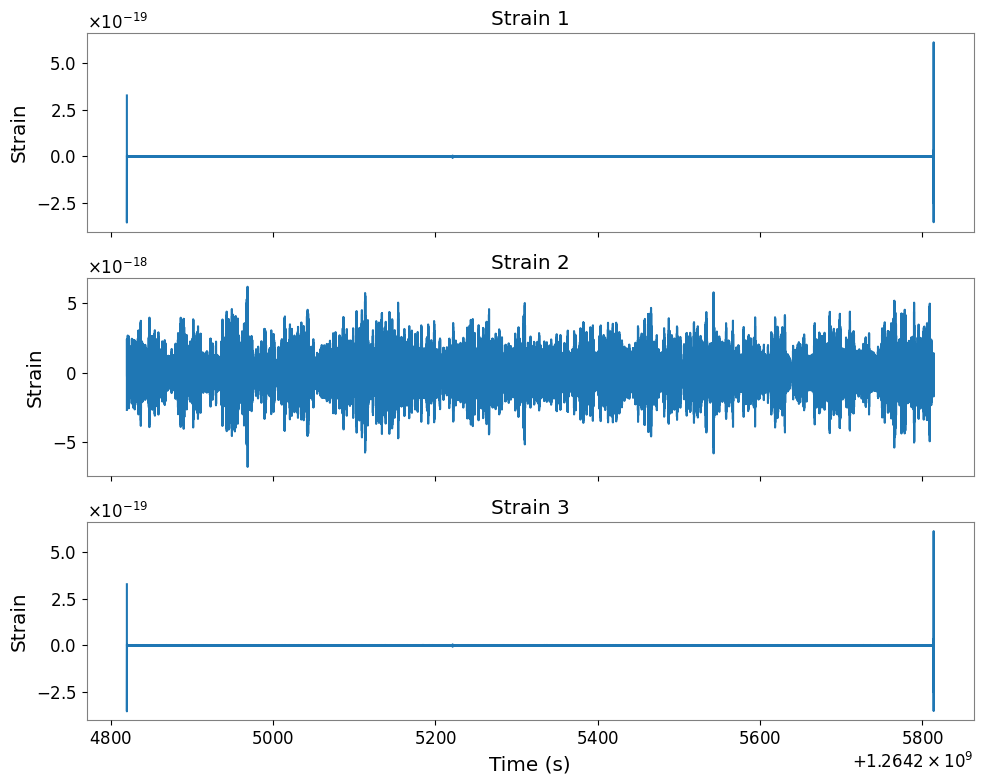

In [13]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots (stacked vertically)
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot strain-1
axs[0].plot(data_1.times.value, data_1.value)
axs[0].set_title("Strain 1")
axs[0].set_ylabel("Strain")
axs[0].grid()

# Plot strain-2
axs[1].plot(data_2.times.value, data_2.value)
axs[1].set_title("Strain 2")
axs[1].set_ylabel("Strain")
axs[1].grid()

# Plot strain-3
axs[2].plot(data_3.times.value, data_3.value)
axs[2].set_title("Strain 3")
axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Strain")
axs[2].grid()

plt.tight_layout()
plt.show()

In [14]:
from pycbc import filter

strain1 = data_1.to_pycbc()

strain1 = filter.highpass(strain1, 10.0)
strain1 = filter.resample_to_delta_t(strain1, 1.0/2048)
strain1 = strain1.crop(2, 2)

psd1 = strain1.psd(4)

In [15]:
strain2 = data_2.to_pycbc()

strain2 = filter.highpass(strain2, 10.0)
strain2 = filter.resample_to_delta_t(strain2, 1.0/2048)
strain2 = strain2.crop(2, 2)

psd2 = strain2.psd(4)

In [16]:
strain3 = data_3.to_pycbc()

strain3 = filter.highpass(strain3, 10.0)
strain3 = filter.resample_to_delta_t(strain3, 1.0/2048)
strain3 = strain3.crop(2, 2)

psd3 = strain3.psd(4)

In [17]:
from pycbc.psd import interpolate, inverse_spectrum_truncation

psd1 = interpolate(psd1, strain1.delta_f)
psd1 = inverse_spectrum_truncation(
    psd1,
    int(4 * strain1.sample_rate),
    low_frequency_cutoff=30
)

In [18]:
psd2 = interpolate(psd2, strain2.delta_f)
psd2 = inverse_spectrum_truncation(
    psd2,
    int(4 * strain2.sample_rate),
    low_frequency_cutoff=30
)

In [19]:
psd3 = interpolate(psd3, strain3.delta_f)
psd3 = inverse_spectrum_truncation(
    psd3,
    int(4 * strain3.sample_rate),
    low_frequency_cutoff=30
)

In [20]:
from pycbc.waveform import get_fd_waveform
from pycbc.filter import matched_filter
from pycbc.conversions import mass1_from_mchirp_q
from pycbc.filter import matched_filter

In [21]:
#Hint masses are some vanilla BBH merger

In [52]:
from pycbc.filter import matched_filter
from pycbc.vetoes import power_chisq
import numpy as np

def compute_snr_chisq(hp, strain, psd, nbins=26, flow=30.0):
    """
    Compute matched-filter SNR and reduced chi-square for given data.

    Parameters:
    -----------
    hp : Frequency-domain template (PyCBC waveform)
    strain : PyCBC TimeSeries
    psd : PyCBC PSD
    nbins : int (default=26)
    flow : float (low frequency cutoff)

    Returns:
    --------
    snr : cropped SNR TimeSeries
    chisq : reduced chi-square TimeSeries
    snr_abs : absolute SNR array
    """

    # --- Matched filter SNR ---
    snr = matched_filter(
        hp,
        strain,
        psd=psd,
        low_frequency_cutoff=flow
    )

    # Crop SNR (remove filter edges)
    snr = snr.crop(2, 2)
    snr_abs = np.abs(snr.numpy())

    # --- Chi-square ---
    chisq = power_chisq(
        hp,
        strain,
        nbins,
        psd,
        low_frequency_cutoff=flow
    )

    # Normalize chi-square
    dof = nbins * 2 - 2
    chisq = chisq.crop(5, 4)
    chisq /= dof

    return snr, chisq, snr_abs

In [221]:
import numpy as np
from pycbc.waveform import get_fd_waveform

N = 40

m1_list = np.random.uniform(10, 70, N)
m2_list = np.random.uniform(10, 70, N)

In [222]:
from pycbc.events.ranking import newsnr

results_1 = []

for m1, m2 in zip(m1_list, m2_list):

    if m1 < m2:
        m1, m2 = m2, m1

    # --- waveform ---
    hp, _ = get_fd_waveform(
        mass1=m1,
        mass2=m2,
        delta_f=strain1.delta_f,
        approximant='IMRPhenomD',
        f_lower=30)

    hp.resize(len(psd1))

    # --- SNR + chisq ---
    snr, chisq, snr_abs = compute_snr_chisq(hp, strain1, psd1)
    times = snr.sample_times

    # --- interpolate chisq to snr time grid ---
    chisq_interp = np.interp(times, chisq.sample_times, chisq)

    # --- reweighted SNR ---
    rw_snr = newsnr(snr_abs, chisq_interp)

    # =========================
    # --- Find 3 peaks ---
    # =========================
    def mask_region(mask, idx, width):
        mask[max(0, idx-width):min(len(mask), idx+width)] = False

    dt = times[1] - times[0]
    w = int(0.1 / dt)

    mask = np.ones_like(snr_abs, dtype=bool)

    # Peak 1
    idx1 = np.argmax(snr_abs)
    t1, s1 = times[idx1], snr_abs[idx1]
    mask_region(mask, idx1, w)

    # Peak 2
    snr_masked = snr_abs.copy()
    snr_masked[~mask] = 0
    idx2 = np.argmax(snr_masked)
    t2, s2 = times[idx2], snr_masked[idx2]
    mask_region(mask, idx2, w)

    # Peak 3
    snr_masked = snr_abs.copy()
    snr_masked[~mask] = 0
    idx3 = np.argmax(snr_masked)
    t3, s3 = times[idx3], snr_masked[idx3]

    # --- helper to get values at time ---
    def get_vals(t):
        idx = np.argmin(np.abs(times - t))
        return float(chisq_interp[idx]), float(rw_snr[idx])

    c1, rw1 = get_vals(t1)
    c2, rw2 = get_vals(t2)
    c3, rw3 = get_vals(t3)

    # --- store ---
    results_1.append({
        "m1": m1,
        "m2": m2,
        "total_mass": m1 + m2,

        "peak1_time": float(t1),
        "peak1_snr": float(s1),
        "peak1_chisq": c1,
        "peak1_rwsnr": rw1,

        "peak2_time": float(t2),
        "peak2_snr": float(s2),
        "peak2_chisq": c2,
        "peak2_rwsnr": rw2,

        "peak3_time": float(t3),
        "peak3_snr": float(s3),
        "peak3_chisq": c3,
        "peak3_rwsnr": rw3
    })

In [223]:
from pycbc.events.ranking import newsnr

results_2 = []

for m1, m2 in zip(m1_list, m2_list):

    if m1 < m2:
        m1, m2 = m2, m1

    hp, _ = get_fd_waveform(
        mass1=m1,
        mass2=m2,
        delta_f=strain2.delta_f,
        approximant='IMRPhenomD',
        f_lower=30
    )

    hp.resize(len(psd2))

    snr, chisq, snr_abs = compute_snr_chisq(hp, strain2, psd2)
    times = snr.sample_times

    chisq_interp = np.interp(times, chisq.sample_times, chisq)
    rw_snr = newsnr(snr_abs, chisq_interp)

    # ---- Peak finding ----
    def mask_region(mask, idx, width):
        mask[max(0, idx-width):min(len(mask), idx+width)] = False

    dt = times[1] - times[0]
    w = int(0.1 / dt)

    mask = np.ones_like(snr_abs, dtype=bool)

    idx1 = np.argmax(snr_abs)
    t1, s1 = times[idx1], snr_abs[idx1]
    mask_region(mask, idx1, w)

    snr_masked = snr_abs.copy()
    snr_masked[~mask] = 0
    idx2 = np.argmax(snr_masked)
    t2, s2 = times[idx2], snr_masked[idx2]
    mask_region(mask, idx2, w)

    snr_masked = snr_abs.copy()
    snr_masked[~mask] = 0
    idx3 = np.argmax(snr_masked)
    t3, s3 = times[idx3], snr_masked[idx3]

    def get_vals(t):
        idx = np.argmin(np.abs(times - t))
        return float(chisq_interp[idx]), float(rw_snr[idx])

    c1, rw1 = get_vals(t1)
    c2, rw2 = get_vals(t2)
    c3, rw3 = get_vals(t3)

    results_2.append({
        "m1": m1,
        "m2": m2,
        "total_mass": m1 + m2,

        "peak1_time": float(t1),
        "peak1_snr": float(s1),
        "peak1_chisq": c1,
        "peak1_rwsnr": rw1,

        "peak2_time": float(t2),
        "peak2_snr": float(s2),
        "peak2_chisq": c2,
        "peak2_rwsnr": rw2,

        "peak3_time": float(t3),
        "peak3_snr": float(s3),
        "peak3_chisq": c3,
        "peak3_rwsnr": rw3
    })

In [224]:
results_3 = []

for m1, m2 in zip(m1_list, m2_list):

    if m1 < m2:
        m1, m2 = m2, m1

    hp, _ = get_fd_waveform(
        mass1=m1,
        mass2=m2,
        delta_f=strain3.delta_f,
        approximant='IMRPhenomD',
        f_lower=30
    )

    hp.resize(len(psd3))

    snr, chisq, snr_abs = compute_snr_chisq(hp, strain3, psd3)
    times = snr.sample_times

    chisq_interp = np.interp(times, chisq.sample_times, chisq)
    rw_snr = newsnr(snr_abs, chisq_interp)

    def mask_region(mask, idx, width):
        mask[max(0, idx-width):min(len(mask), idx+width)] = False

    dt = times[1] - times[0]
    w = int(0.1 / dt)

    mask = np.ones_like(snr_abs, dtype=bool)

    idx1 = np.argmax(snr_abs)
    t1, s1 = times[idx1], snr_abs[idx1]
    mask_region(mask, idx1, w)

    snr_masked = snr_abs.copy()
    snr_masked[~mask] = 0
    idx2 = np.argmax(snr_masked)
    t2, s2 = times[idx2], snr_masked[idx2]
    mask_region(mask, idx2, w)

    snr_masked = snr_abs.copy()
    snr_masked[~mask] = 0
    idx3 = np.argmax(snr_masked)
    t3, s3 = times[idx3], snr_masked[idx3]

    def get_vals(t):
        idx = np.argmin(np.abs(times - t))
        return float(chisq_interp[idx]), float(rw_snr[idx])

    c1, rw1 = get_vals(t1)
    c2, rw2 = get_vals(t2)
    c3, rw3 = get_vals(t3)

    results_3.append({
        "m1": m1,
        "m2": m2,
        "total_mass": m1 + m2,

        "peak1_time": float(t1),
        "peak1_snr": float(s1),
        "peak1_chisq": c1,
        "peak1_rwsnr": rw1,

        "peak2_time": float(t2),
        "peak2_snr": float(s2),
        "peak2_chisq": c2,
        "peak2_rwsnr": rw2,

        "peak3_time": float(t3),
        "peak3_snr": float(s3),
        "peak3_chisq": c3,
        "peak3_rwsnr": rw3
    })

In [225]:
arr_1 = np.array([
    [
        r["m1"],
        r["m2"],
        r["total_mass"],

        r["peak1_snr"],
        r["peak1_chisq"],
        r["peak1_rwsnr"],

        r["peak2_snr"],
        r["peak2_chisq"],
        r["peak2_rwsnr"],

        r["peak3_snr"],
        r["peak3_chisq"],
        r["peak3_rwsnr"]
    ]
    for r in results_1
])

In [226]:
arr_2 = np.array([
    [
        r["m1"],
        r["m2"],
        r["total_mass"],

        r["peak1_snr"],
        r["peak1_chisq"],
        r["peak1_rwsnr"],

        r["peak2_snr"],
        r["peak2_chisq"],
        r["peak2_rwsnr"],

        r["peak3_snr"],
        r["peak3_chisq"],
        r["peak3_rwsnr"]
    ]
    for r in results_2
])

In [227]:
arr_3 = np.array([
    [
        r["m1"],
        r["m2"],
        r["total_mass"],

        r["peak1_snr"],
        r["peak1_chisq"],
        r["peak1_rwsnr"],

        r["peak2_snr"],
        r["peak2_chisq"],
        r["peak2_rwsnr"],

        r["peak3_snr"],
        r["peak3_chisq"],
        r["peak3_rwsnr"]
    ]
    for r in results_3
])

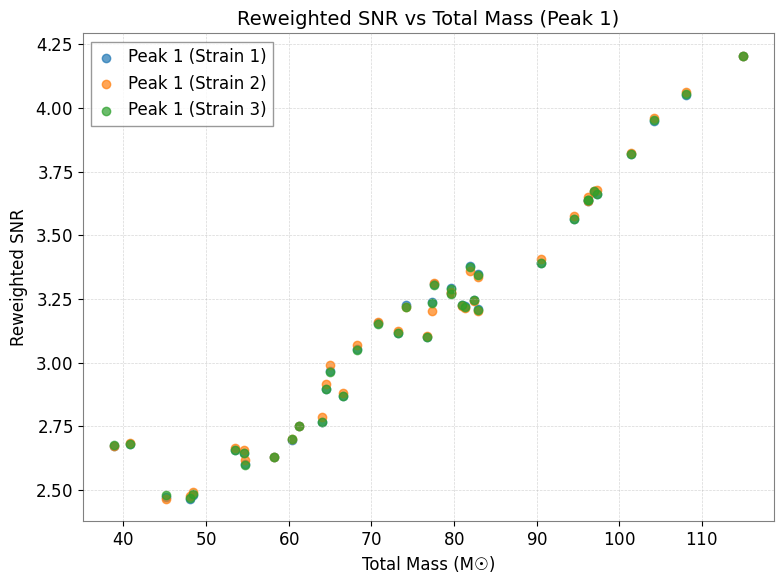

In [235]:
plt.figure(figsize=(8,6))

# Scatter plots
plt.scatter(arr_1[:, 2], arr_1[:, 5], label="Peak 1 (Strain 1)", alpha=0.7)
plt.scatter(arr_2[:, 2], arr_2[:, 5], label="Peak 1 (Strain 2)", alpha=0.7)
plt.scatter(arr_3[:, 2], arr_3[:, 5], label="Peak 1 (Strain 3)", alpha=0.7)

# Labels
plt.xlabel("Total Mass (M☉)", fontsize=12)
plt.ylabel("Reweighted SNR", fontsize=12)

# Title
plt.title("Reweighted SNR vs Total Mass (Peak 1)", fontsize=14)

# Grid & legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

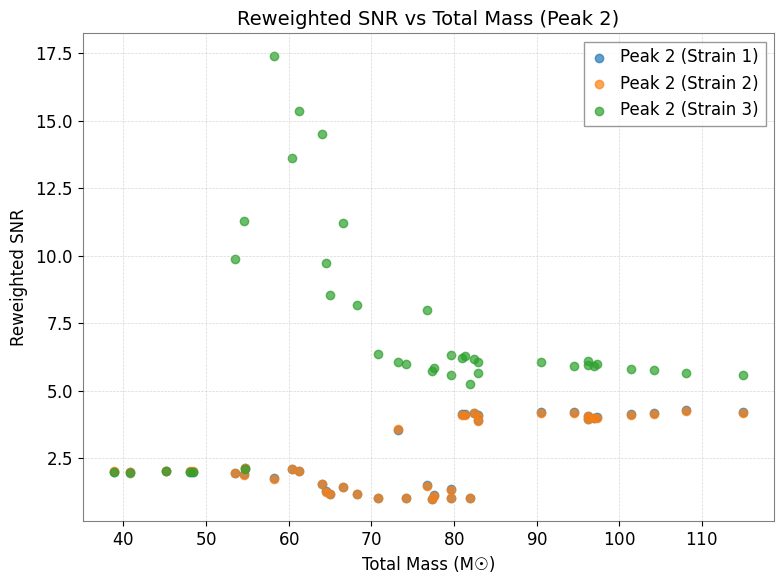

In [237]:
plt.figure(figsize=(8,6))

# Scatter plots (Peak 2 reweighted SNR)
plt.scatter(arr_1[:, 2], arr_1[:, 8], label="Peak 2 (Strain 1)", alpha=0.7)
plt.scatter(arr_2[:, 2], arr_2[:, 8], label="Peak 2 (Strain 2)", alpha=0.7)
plt.scatter(arr_3[:, 2], arr_3[:, 8], label="Peak 2 (Strain 3)", alpha=0.7)

# Labels
plt.xlabel("Total Mass (M☉)", fontsize=12)
plt.ylabel("Reweighted SNR", fontsize=12)

# Title
plt.title("Reweighted SNR vs Total Mass (Peak 2)", fontsize=14)

# Grid & legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [242]:
idx = np.argmax(arr_3[:, 6])

best_m1 = arr_3[idx, 0]
best_m2 = arr_3[idx, 1]
best_snr = arr_3[idx, 6]
best_chisq = arr_3[idx, 7]

print("Best (Peak 2 SNR):")
print("m1 =", best_m1)
print("m2 =", best_m2)
print("Peak2 SNR =", best_snr)
print("Peak2 chi^2 =", best_chisq)

Best (Peak 2 SNR):
m1 = 31.662868548094877
m2 = 26.549829890884343
Peak2 SNR = 17.960424410908086
Peak2 chi^2 = 1.1219325843642822


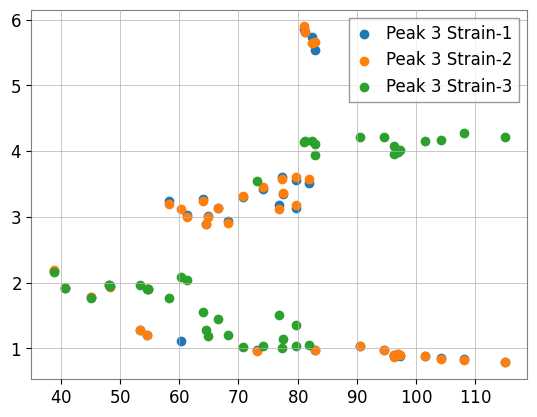

In [240]:
plt.scatter(arr_1[:, 2], arr_1[:, 11], label="Peak 3 Strain-1")
plt.scatter(arr_2[:, 2], arr_2[:, 11], label="Peak 3 Strain-2")
plt.scatter(arr_3[:, 2], arr_3[:, 11], label="Peak 3 Strain-3")
plt.legend()

## From the reweighted SNR analysis, Strain 3 shows the strongest evidence of a potential binary black hole (BBH) signal. The relatively higher reweighted SNR, along with lower χ² values, indicates better consistency with the template waveform, suggesting that a physically meaningful signal is most likely present in Strain 3.

### FOLLOWING IS JUST THE ANALYSIS OF THIS TEMPLATE WE FOUND WITH THE DATA IN STRAIN-3 AROUND THE MASS RANGE WE JUST FOUND ABOVE

In [248]:
m1 = 31.662868548094877
m2 = 26.549829890884343

In [249]:
hp_phenom_b, _ = get_fd_waveform(
        mass1=m1,
        mass2=m2,
        delta_f=strain3.delta_f,
        approximant='IMRPhenomD',
        f_lower=30
    )
hp_phenom_b.resize(len(psd3))

In [251]:
snr = matched_filter(hp_phenom_b, strain3, psd3, low_frequency_cutoff=30)
snr = snr.crop(2, 2)
snr_abs = np.abs(snr.numpy())
times = snr.sample_times

In [252]:
from pycbc.vetoes import power_chisq
from pycbc.events.ranking import newsnr

# ---------- SETTINGS ----------
nbins = 26
flow = 30.0

# ---------- HELPER ----------
def mask_region(mask, idx, width):
    mask[max(0, idx-width):min(len(mask), idx+width)] = False

# ---------- WINDOW ----------
dt = times[1] - times[0]
w = int(0.1 / dt)

mask = np.ones_like(snr_abs, dtype=bool)

# ---------- PEAK 1 ----------
idx1 = np.argmax(snr_abs)
t1, s1 = times[idx1], snr_abs[idx1]
mask_region(mask, idx1, w)

# ---------- PEAK 2 ----------
snr_masked = snr_abs.copy()
snr_masked[~mask] = 0
idx2 = np.argmax(snr_masked)
t2, s2 = times[idx2], snr_masked[idx2]
mask_region(mask, idx2, w)

# ---------- PEAK 3 ----------
snr_masked = snr_abs.copy()
snr_masked[~mask] = 0
idx3 = np.argmax(snr_masked)
t3, s3 = times[idx3], snr_masked[idx3]

# ---------- CHI-SQUARE ----------
chisq = power_chisq(
    hp_phenom_b,
    strain3,
    nbins,
    psd3,
    low_frequency_cutoff=flow
)

chisq = chisq.crop(5, 4)
chisq /= (nbins * 2 - 2)

# ---------- INTERPOLATION ----------
chisq_interp = np.interp(times, chisq.sample_times, chisq)

# ---------- REWEIGHTED SNR ----------
reweighted = newsnr(snr_abs, chisq_interp)

# ---------- EXTRACT VALUES ----------
def get_vals(t):
    idx = np.argmin(np.abs(times - t))
    return float(chisq_interp[idx]), float(reweighted[idx])

c1, rw1 = get_vals(t1)
c2, rw2 = get_vals(t2)
c3, rw3 = get_vals(t3)

# ---------- MERGER TIME (BEST PEAK) ----------
rw_list = [rw1, rw2, rw3]
t_list = [t1, t2, t3]

best_idx = np.argmax(rw_list)
t_merger = t_list[best_idx]

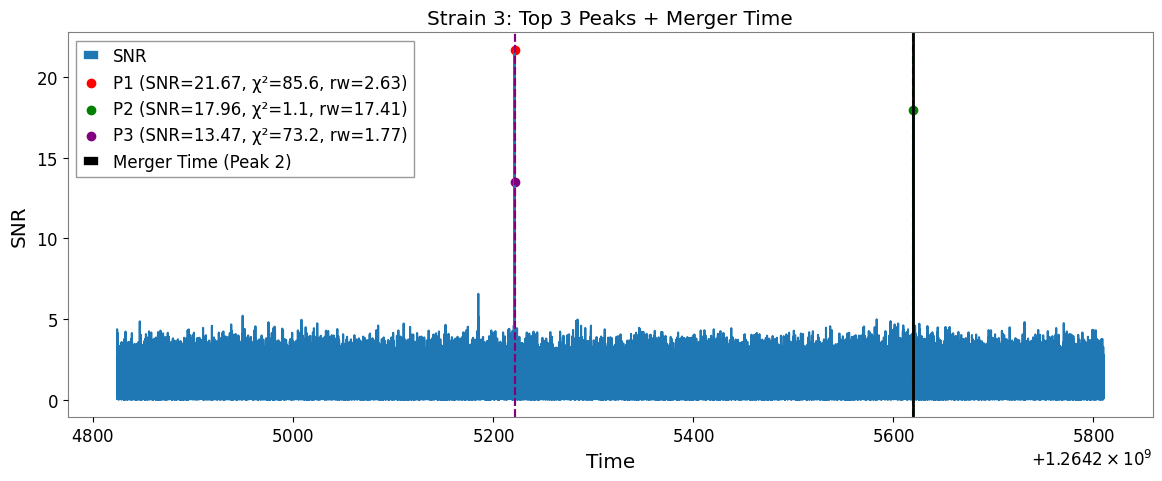


Strain 3 Results:
Peak1 -> Time=1264205221.4423828, SNR=21.670834227234167, χ²=85.56716230778044, rwSNR=2.6296237626294587
Peak2 -> Time=1264205619.9995117, SNR=17.960424410908086, χ²=1.1219325843642822, rwSNR=17.408137602457803
Peak3 -> Time=1264205221.5473633, SNR=13.472439666583254, χ²=73.23442557451969, rwSNR=1.7670957782446297

Estimated Merger Time: 1264205619.9995117 (from Peak 2)


In [253]:
# ---------- PLOT ----------
plt.figure(figsize=(14,5))
plt.plot(times, snr_abs, label="SNR")

plt.scatter([t1], [s1], color='r',
            label=f"P1 (SNR={s1:.2f}, χ²={c1:.1f}, rw={rw1:.2f})")
plt.scatter([t2], [s2], color='g',
            label=f"P2 (SNR={s2:.2f}, χ²={c2:.1f}, rw={rw2:.2f})")
plt.scatter([t3], [s3], color='purple',
            label=f"P3 (SNR={s3:.2f}, χ²={c3:.1f}, rw={rw3:.2f})")

plt.axvline(t1, color='r', linestyle='--')
plt.axvline(t2, color='g', linestyle='--')
plt.axvline(t3, color='purple', linestyle='--')

# highlight merger time
plt.axvline(t_merger, color='black', linestyle='-', linewidth=2,
            label=f"Merger Time (Peak {best_idx+1})")

plt.title("Strain 3: Top 3 Peaks + Merger Time")
plt.xlabel("Time")
plt.ylabel("SNR")
plt.legend()
plt.grid()
plt.show()

# ---------- PRINT ----------
print("\nStrain 3 Results:")
print(f"Peak1 -> Time={t1}, SNR={s1}, χ²={c1}, rwSNR={rw1}")
print(f"Peak2 -> Time={t2}, SNR={s2}, χ²={c2}, rwSNR={rw2}")
print(f"Peak3 -> Time={t3}, SNR={s3}, χ²={c3}, rwSNR={rw3}")

print(f"\nEstimated Merger Time: {t_merger} (from Peak {best_idx+1})")

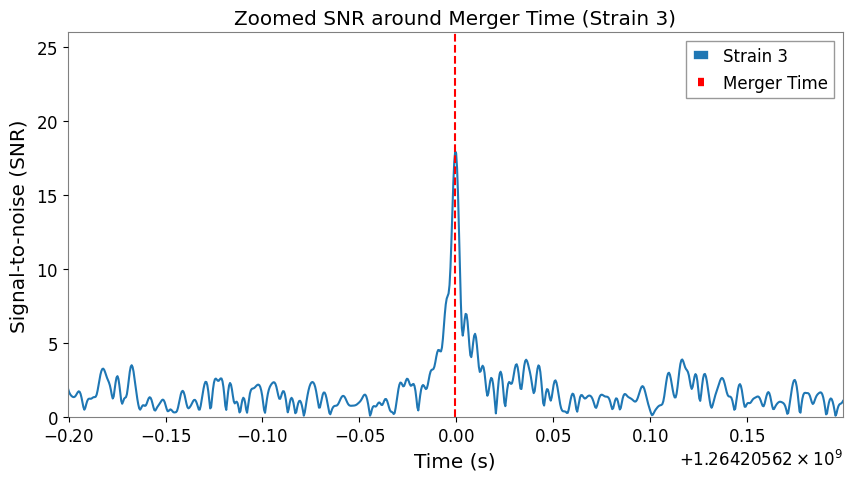

In [254]:
# ---- Zoomed SNR plot around merger ----
w = 0.2   # window in seconds (adjust if needed)

plt.figure(figsize=(10,5))

plt.plot(snr.sample_times, np.abs(snr.numpy()), label="Strain 3")

# mark merger time
plt.axvline(t_merger, color='r', linestyle='--', label="Merger Time")

plt.xlim(t_merger - w, t_merger + w)
plt.ylim(0, np.max(np.abs(snr.numpy())) * 1.2)

plt.xlabel("Time (s)")
plt.ylabel("Signal-to-noise (SNR)")
plt.title("Zoomed SNR around Merger Time (Strain 3)")
plt.legend()
plt.grid()

plt.show()

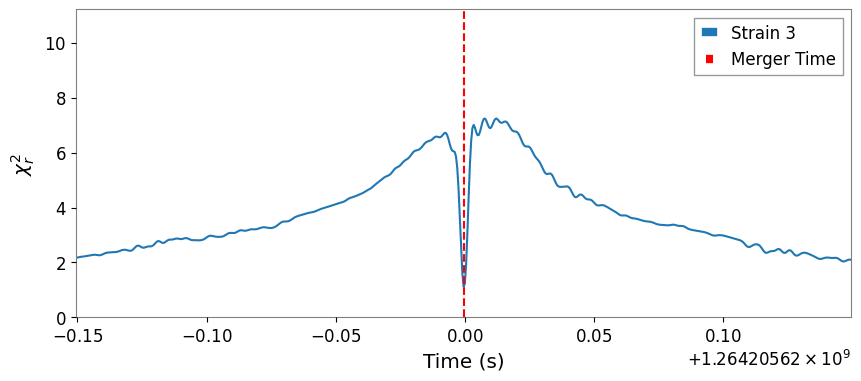

In [260]:
plt.figure(figsize=(10,4))

plt.plot(chisq.sample_times, chisq.numpy(), label="Strain 3")

plt.axvline(t_merger, color='r', linestyle='--', label="Merger Time")

plt.xlim(t_merger - 0.15, t_merger + 0.15)
plt.ylim(0, c2 * 10)

plt.xlabel("Time (s)")
plt.ylabel(r'$\chi^2_r$')
plt.legend()
plt.grid()

plt.show()

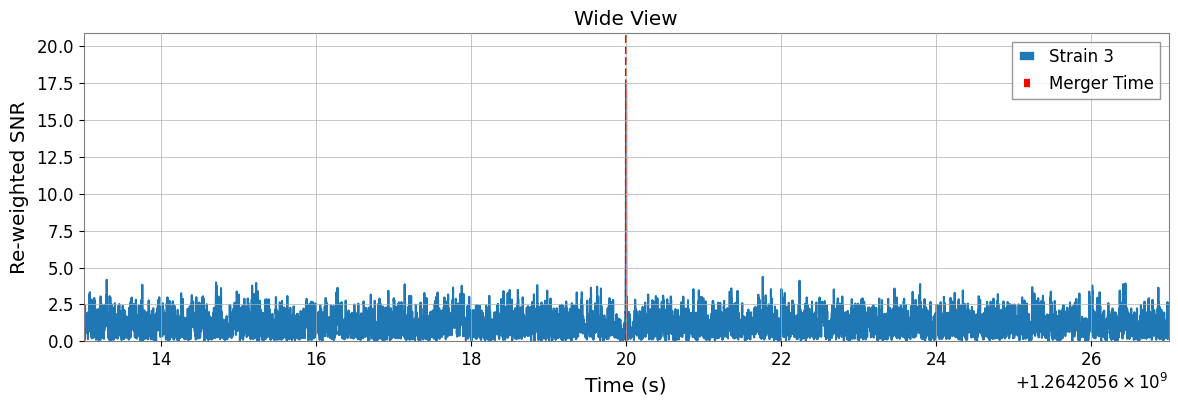

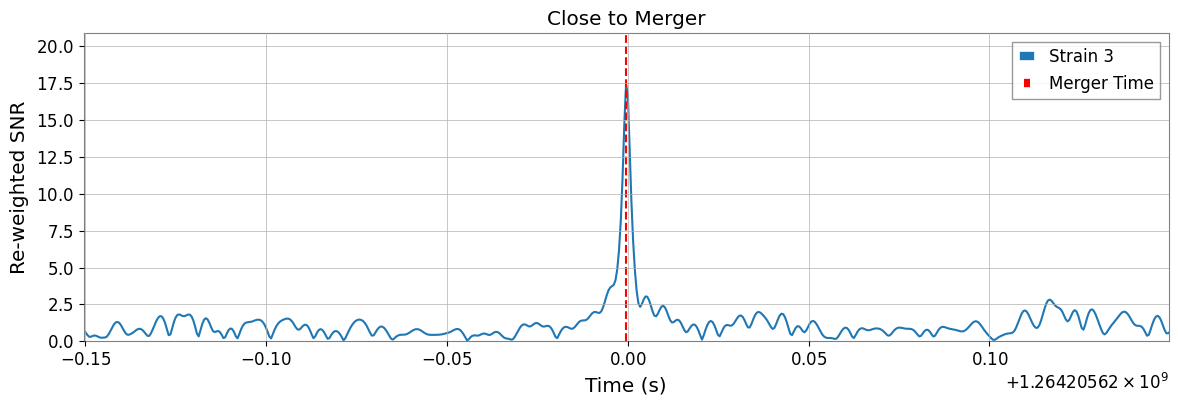

In [261]:
# --- Reweighted SNR ---
nsnr = newsnr(snr_abs, chisq_interp)

# --- Plot: Wide + Zoom views ---
for w, title in [(7, 'Wide View'), (0.15, 'Close to Merger')]:

    plt.figure(figsize=(14,4))

    plt.plot(times, nsnr, label="Strain 3")

    # mark merger time
    plt.axvline(t_merger, color='r', linestyle='--', label="Merger Time")

    plt.legend()
    plt.title(title)
    plt.grid(True)

    plt.xlim(t_merger - w, t_merger + w)
    plt.ylim(0, max(nsnr) * 1.2)

    plt.xlabel('Time (s)')
    plt.ylabel('Re-weighted SNR')

    plt.show()

In [262]:
from pycbc.waveform import get_td_waveform

# --- masses from your best candidate ---
m1 = 31.662868548094877
m2 = 26.549829890884343

# --- Generate time-domain waveform ---
hp_td, hc_td = get_td_waveform(
    approximant="IMRPhenomXPHM",   # you can also use IMRPhenomD if consistent
    mass1=m1,
    mass2=m2,
    delta_t=strain3.delta_t,
    f_lower=30
)

# --- Resize to match data length ---
hp_td.resize(len(strain3))

# --- Shift waveform so merger aligns properly ---
template = hp_td.cyclic_time_shift(hp_td.start_time)

In [263]:
time = t_merger
idx = np.argmin(np.abs(snr.sample_times - time))
snrp = snr[idx]

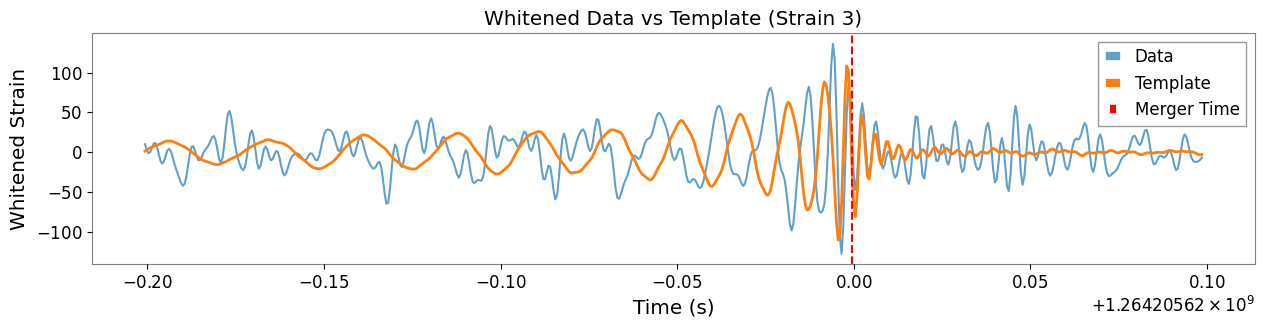

In [267]:
from pycbc.filter import sigma
hp_td, _ = get_td_waveform(
    approximant="IMRPhenomXPHM",
    mass1=m1,
    mass2=m2,
    delta_t=strain3.delta_t,
    f_lower=30
)

hp_td.resize(len(strain3))

# ---------- ALIGN TEMPLATE ----------
dt = time - strain3.start_time
template = hp_td.cyclic_time_shift(hp_td.start_time)
aligned = template.cyclic_time_shift(dt)

# ---------- NORMALIZE ----------
aligned /= sigma(aligned, psd=psd3, low_frequency_cutoff=30.0)

# ---------- SCALE WITH SNR ----------
aligned = (aligned.to_frequencyseries() * snrp).to_timeseries()
aligned.start_time = strain3.start_time

# ---------- WHITEN DATA ----------
white_data = (strain3.to_frequencyseries() / psd3**0.5).to_timeseries()

# ---------- WHITEN TEMPLATE ----------
tapered = aligned.highpass_fir(30, 512, remove_corrupted=False)
white_template = (tapered.to_frequencyseries() / psd3**0.5).to_timeseries()

# ---------- BANDPASS ----------
white_data = white_data.highpass_fir(30., 512).lowpass_fir(300, 512)
white_template = white_template.highpass_fir(30, 512).lowpass_fir(300, 512)

# ---------- ZOOM AROUND MERGER ----------
white_data = white_data.time_slice(t_merger - 0.2, t_merger + 0.1)
white_template = white_template.time_slice(t_merger - 0.2, t_merger + 0.1)

# ---------- PLOT ----------
plt.figure(figsize=(15,3))

plt.plot(white_data.sample_times, white_data, label="Data", alpha=0.7)
plt.plot(white_template.sample_times, -white_template, label="Template", linewidth=2)

plt.axvline(t_merger, color='r', linestyle='--', label="Merger Time")

plt.xlabel("Time (s)")
plt.ylabel("Whitened Strain")
plt.title("Whitened Data vs Template (Strain 3)")
plt.legend()
plt.grid()

plt.show()